In [1]:
import sys 
sys.path.insert(0,'../Modules/')
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from Block_WLS import Block_WLS
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
from index_set import index_set
from pde_solvers import Viscous_Burgers_Spectral_Galerkin, sine_basis_vandermonde

def v_rel_errs(v):
    induced = True   
    lift_dim = 200
    idx_param = 60
    idx_type = 'hc'
    if v in [1,0.1,0.01]:
        dt = 0.001
    else:
        dt = 0.0001                            
                          
    ### Approximation space parameters 
    max_poly_degree =   10               # Maximum univariate degree of polynomials used to define operator basis 
    input_mode_truncation = 20           # Truncated Dimension of Input Function Space 
    M_test = 1000                        # Number of test samples

    ### PDE parameters & solver for Viscous Burgers
    T = 0.2                              # Final time for integration          
    def pde_eval(input_data):
        M = input_data.shape[0]
        input_data_lifted = np.zeros([M, lift_dim])
        input_data_lifted[:, :input_mode_truncation] = input_data
        output_data = Viscous_Burgers_Spectral_Galerkin(v, dt, int(T/dt), input_data_lifted)#[:, :output_mode_truncation]
        if not np.all(np.isfinite(np.linalg.norm(output_data, axis=1))):
            raise ValueError("Encountered inf/nan while solving PDE. Probably you want to decrease dt")
        return output_data

    jacobi_params = [[a**2, a**2]for a in range(input_mode_truncation)]

    ### Build Index Set
    weights = np.linspace(1, 0.01, input_mode_truncation)
    idx_set = index_set(input_mode_truncation, idx_param, max_index=max_poly_degree, weights=weights, max_size=10000, type=idx_type, p_norm = 2)    
    N = idx_set.shape[0]
    M = int(N * np.log(N))

    ### Generate Training Data:
    if induced:
        input_samples = Jacobi_Tensor_Induced_Sampling(M, idx_set, jacobi_params, max_poly_degree)
    else: 
        input_samples = jacobi_tensor_samp(jacobi_params, M)
    output_samples = pde_eval(input_samples)

    ### Generate Testing Data:
    test_input_samples = jacobi_tensor_samp(jacobi_params, M_test)
    test_output_samples = pde_eval(test_input_samples)

    ### Instantiate the operator learning object.
    wls_operator = Block_WLS(jacobi_params, idx_set, input_samples,output_samples, induced)

    
    ### Check error decay in output modes
    V = wls_operator.build_vandermonde(test_input_samples)
    dims = np.arange(2,200,10)
    rel_errs = []
    for dim in dims:
        C = np.zeros_like(wls_operator.C)
        C[:, :dim] = wls_operator.C[:, :dim]
        test_out = V@C
        rel_errs.append(
            np.sqrt(np.mean(np.linalg.norm(test_out - test_output_samples, axis = 1)**2))/np.sqrt(np.mean(np.linalg.norm(test_output_samples, axis = 1)**2))
        )
    return rel_errs

vs = []
rel_errs = []
dims = np.arange(2,200,10)
for v in [1,0.1,0.01,0.001]:
    print(f"Starting {v} viscosity run...")
    vs.append(v)
    rel_errs.append(v_rel_errs(v))
np.save("Data/out_dim_dat.npy", rel_errs)

Starting 1 viscosity run...
Starting 0.1 viscosity run...
Starting 0.01 viscosity run...
Starting 0.001 viscosity run...


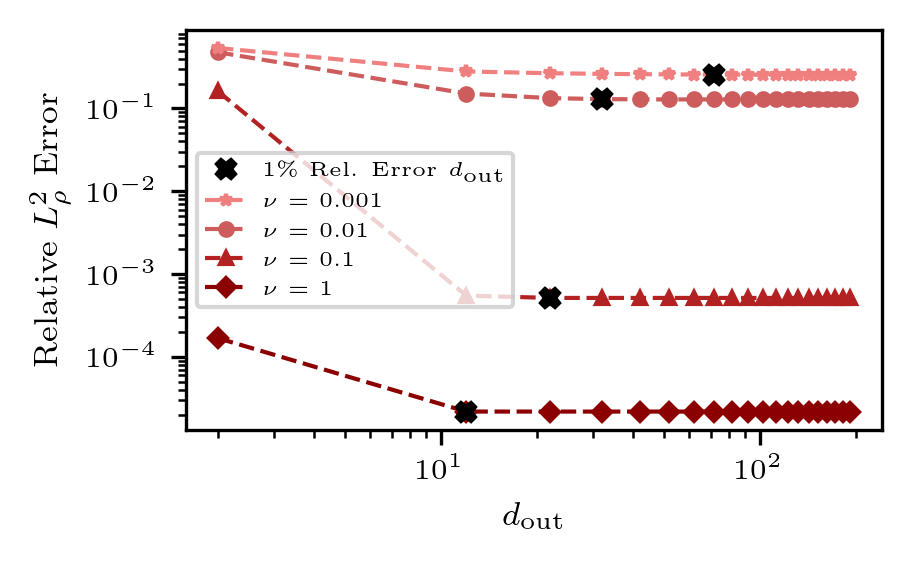

In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1 
import numpy as np 

rel_errs = np.load("Data/out_dim_dat.npy")
dims = np.arange(2,200,10) 
vs = [1,0.1,0.01,0.001]
mpl.rcParams['figure.dpi'] = 300
colors = ["darkred","firebrick","indianred", "lightcoral"]
markers = ["D", "^", "o", "*"]

def get_thresh(arr):
    idx = np.argmin(
        np.abs(1 - (np.array(arr) - arr[-1])/arr[-1] * 100 ))
    return idx

fig,ax = plt.subplots(figsize = (fig_width,fig_height), layout= 'constrained')
for i,v in enumerate(vs): 
    ax.plot(dims, rel_errs[i], marker = markers[i],linestyle = "--",color = colors[i], label = rf"$\nu$ = {v}", linewidth = linewidth_large, markersize = markersize_large)
    idx = get_thresh(rel_errs[i])
    if i == 3:
        ax.plot(dims[idx], rel_errs[i][idx],'kX', markersize = markersize_large + 1.5, label = r"$1\%$ Rel. Error $d_{\mathrm{out}}$ ")
    else:
        ax.plot(dims[idx], rel_errs[i][idx],'kX', markersize = markersize_large + 1.5)
    
    ax.set(
        yscale='log',
        xscale = 'log',
        xlabel = r"$d_{\mathrm{out}}$",
        ylabel = r"Relative $L^2_{\rho}$ Error") 
        #title = r" $d_o$ achieving less than 1% relative truncation error")
    
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='best')
plt.savefig("Plots/vb_truncation_error_with_viscosity.pdf", bbox_inches = 'tight')
